In [1]:
# Autoreload imported modules when running a cell so we don't have to
# restart the notebook as often
%load_ext autoreload
%autoreload 2

In [2]:
from simulations.envelope import a_d_envelope, TIME_END, TIME_START, EnvelopeSettings
import numpy as np
import matplotlib.pyplot as plt

def settings_label(s: EnvelopeSettings) -> str:
    return f"a={s.attack}, d={s.decay}, s={s.shape}, amp={s.amplitude}"

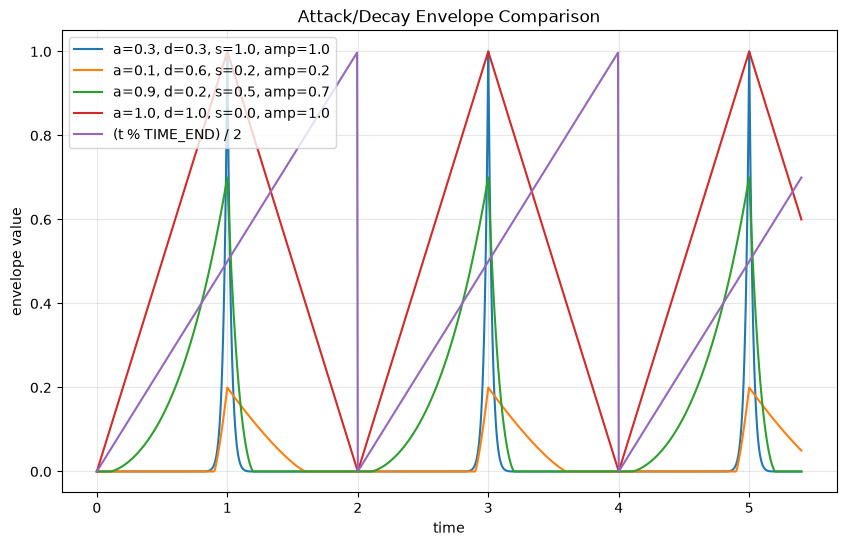

In [3]:
# Time axis: 0 to TIME_END*2.7
t_max = TIME_END * 2.7
times = np.linspace(TIME_START, t_max, 1000)

# Define a few parameter combinations to compare
combos = [
    EnvelopeSettings(attack=0.3, decay=0.3, shape=1.0, amplitude=1.0),
    EnvelopeSettings(attack=0.1, decay=0.6, shape=0.2, amplitude=0.2),
    EnvelopeSettings(attack=0.9, decay=0.2, shape=0.5, amplitude=0.7),
    EnvelopeSettings(attack=1.0, decay=1.0, shape=0.0, amplitude=1.0),
]

plt.figure(figsize=(10, 6))

for combo in combos:
    # a_d_envelope asserts time <= TIME_END, so clip times beyond that to TIME_END
    # (the function returns 0 there anyway since time > TIME_MIDPOINT + decay)
    offset_values = [
        a_d_envelope(combo, t % TIME_END)
        for t in times
    ]
    plt.plot(times, offset_values, label=settings_label(combo))
plt.plot(times, [(t%TIME_END)/2 for t in times], label="(t % TIME_END) / 2")

plt.xlabel("time")
plt.ylabel("envelope value")
plt.title("Attack/Decay Envelope Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

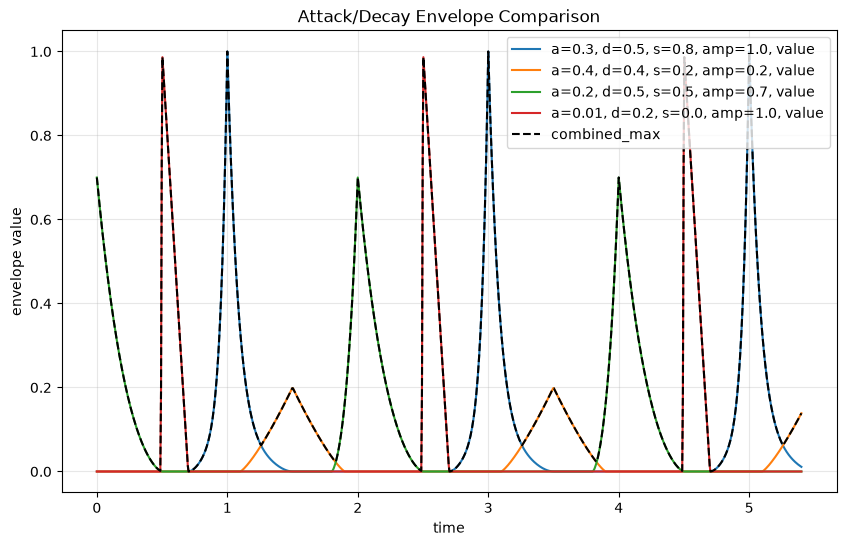

In [4]:
from simulations.envelope import EnvelopeStatus, combine_envelopes, combine_max, offset_envelopes


combos = [
    EnvelopeSettings(attack=0.3, decay=0.5, shape=0.8, amplitude=1.0),
    EnvelopeSettings(attack=0.4, decay=0.4, shape=0.2, amplitude=0.2),
    EnvelopeSettings(attack=0.2, decay=0.5, shape=0.5, amplitude=0.7),
    EnvelopeSettings(attack=0.01, decay=0.2, shape=0.0, amplitude=1.0),
]

plt.figure(figsize=(10, 6))

offset_values = [
    offset_envelopes(combos, t % TIME_END)
    for t in times
]
combined_values = [
    combine_envelopes(s, combine_max)
    for s in offset_values
]
samples_per_envelope: list[list[EnvelopeStatus]] = [[] for _ in combos]
for sample in offset_values:
    for i, env in enumerate(sample):
        samples_per_envelope[i].append(env)

for i, samples in enumerate(samples_per_envelope):
    plt.plot(times, [s.value for s in samples], label=f"{settings_label(combos[i])}, value")

plt.plot(times, combined_values, label="combined_max", linestyle="--", color="black")

plt.xlabel("time")
plt.ylabel("envelope value")
plt.title("Attack/Decay Envelope Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()